# Receding-Horizon MPC via a Cached Harmonic Extension

This example is the closed-loop counterpart of
[Multi-Agent Target Tracking via a Time-Expanded Cellular Sheaf](multi_quadrotor_target_tracking.md).
There, a single time-expanded sheaf is solved over the whole horizon and the
energy-minimizing global section is read off directly.  Here we build a
**model-predictive controller** (MPC) that re-plans at every timestep and show
that the time-homogeneity of the tracking sheaf collapses each per-step solve
into a single matrix-vector product.

**Vehicle model.** Each agent is a planar quadrotor with state
$x = [y,\,z,\,\varphi,\,\dot y,\,\dot z,\,\dot\varphi]^\top \in \mathbb{R}^6$
and control $u = [T_1,T_2]^\top \in \mathbb{R}^2$, linearized about hover and
discretized by zero-order hold at period $h$.

**Sheaf structure.** The time-expanded sheaf has one vertex per
$(\text{entity},\, t)$ pair with stalk $\mathbb{R}^{n_x+n_u}$.
Three edge families encode:
1. *Dynamics*: $x_{t+1} = A_d x_t + B_d u_t$ for each agent and target.
2. *Consensus*: inter-agent agreement on a chosen coordinate subspace.
3. *Tracking*: agent-target alignment in a chosen coordinate subspace.

**MPC formulation.** At each timestep $t$ the controller:
1. Extracts the window sub-problem on $[t,\, t+W]$.
2. Pins the current agent state and the next $W$ target samples as *boundary* $B$.
3. Solves for the free *interior* vertices $I$ via harmonic extension, finding
   the section of minimum Laplacian energy consistent with the boundary:
   $$
   x_I = -L_{II}^{+} L_{IB}\, x_B.
   $$
4. Applies only the first control $u_t$, advances the true dynamics, and repeats.

When $L_{II}$ is singular its nullspace $N = \ker L_{II}$ represents free
coordination degrees of freedom.  A control cost $Q$ selects the cost-optimal
representative via the projection
$$
M = \bigl(I - N(N^\top Q N)^{+} N^\top Q\bigr)\bigl(-L_{II}^{+} L_{IB}\bigr),
$$
so that every per-step solve is the single dense matvec $x_I = M\, x_B$.

The problem-construction and solve utilities used below come from
`CellularSheaves.ControlSheaves.MultiAgentTracking`.

- Problem specification is written with `@tracking_problem` from
  `CellularSheaves.ControlSheaves.TrackingDSL`.
- The open-loop solver pipeline is `build_boundary -> run_scenario`.
- The closed-loop pipeline is `run_mpc_scenario`.
- Animations are produced by `animate_tracking_xy`, implemented by the plotting
  extension when `Plots` is loaded.

In [1]:
using CellularSheaves
using CellularSheaves.ControlSheaves.MultiAgentTracking
using CellularSheaves.ControlSheaves.TrackingDSL
using CellularSheaves.TrajectorySheaves: continuous_to_discrete_zoh
using LinearAlgebra
using Printf
using Plots

## Sliding-Window Structure

The diagram below shows one MPC step at $t = 3$ with window $W = 4$.
Filled vertices are pinned (boundary $B$) and open vertices are solved
(interior $I$).  Arrows within the window show the dynamics edges
$(A_d, B_d)$ and dashed vertical arrows show the tracking edges.

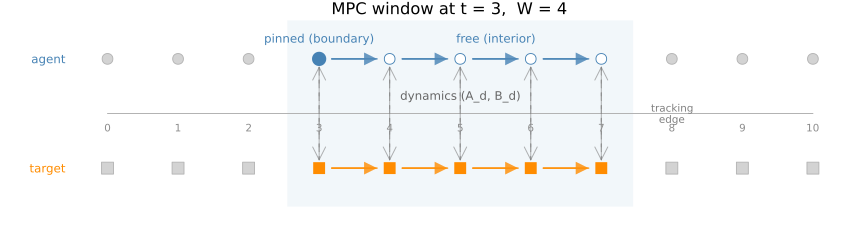

In [2]:
let
    k_d   = 10
    t_now = 3
    W_d   = 4
    t_end = t_now + W_d
    ay    =  0.85
    ty    = -0.85

    p = plot(size=(860, 230), legend=false, framestyle=:none,
             xlims=(-0.8, k_d + 0.5), ylims=(-1.45, 1.45),
             title="MPC window at t = $t_now,  W = $W_d",
             titlefontsize=11)

    vspan!(p, [t_now - 0.45, t_end + 0.45]; color=:steelblue, alpha=0.07, label="")
    plot!(p, [0, k_d], [0.0, 0.0]; color=:gray70, lw=1)
    for t in 0:k_d
        annotate!(p, t, -0.22, text("$t", 7, :center, :gray55))
    end
    for t in t_now:t_end-1
        for (row, col) in ((ay, :steelblue), (ty, :darkorange))
            plot!(p, [t + 0.18, t + 0.82], [row, row];
                  color=col, lw=1.6, arrow=(:closed, 0.3), alpha=0.8)
        end
    end
    for t in t_now:t_end
        plot!(p, [t, t], [ay - 0.13, ty + 0.13];
              color=:gray50, lw=1, ls=:dash, alpha=0.6, arrow=(:both, 0.22))
    end
    for t in 0:k_d
        in_w = t_now <= t <= t_end
        fill_a = (t == t_now) ? :steelblue : (in_w ? :white : :lightgray)
        scatter!(p, [t], [ay]; color=fill_a,
                 markerstrokecolor=(in_w ? :steelblue : :gray70),
                 markerstrokewidth=2, markersize=(t == t_now ? 8 : 6), markershape=:circle)
        scatter!(p, [t], [ty]; color=(in_w ? :darkorange : :lightgray),
                 markerstrokecolor=(in_w ? :darkorange : :gray70),
                 markerstrokewidth=2, markersize=6, markershape=:rect)
    end
    annotate!(p, -0.6, ay, text("agent",  8, :right, :steelblue))
    annotate!(p, -0.6, ty, text("target", 8, :right, :darkorange))
    annotate!(p, t_now,       ay + 0.32, text("pinned (boundary)", 8, :center, :steelblue))
    annotate!(p, t_now + 2.5, ay + 0.32, text("free (interior)",   8, :center, :steelblue))
    annotate!(p, t_now + W_d/2, 0.28,   text("dynamics (A_d, B_d)", 8, :center, :gray40))
    annotate!(p, t_end + 1.0, (ay+ty)/2, text("tracking\nedge", 7, :center, :gray50))
    p
end

## Planar Quadrotor Dynamics

State: $x = [y, z, \varphi, \dot y, \dot z, \dot\varphi]$.
The linearisation is taken around the hover trim condition.
Dynamics, projection matrices, bobbing targets, and helper utilities are set
up identically to the open-loop example.

In [3]:
g      = 9.81
m_veh  = 0.5
I_quad = 0.01
ell    = 0.25

Ac = [0.0  0.0   0.0   1.0  0.0  0.0;
      0.0  0.0   0.0   0.0  1.0  0.0;
      0.0  0.0   0.0   0.0  0.0  1.0;
      0.0  0.0  -g     0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0;
      0.0  0.0   0.0   0.0  0.0  0.0]

Bc = [0.0               0.0;
      0.0               0.0;
      0.0               0.0;
      0.0               0.0;
      1.0 / m_veh       1.0 / m_veh;
      ell / (2I_quad)  -ell / (2I_quad)]

h = 0.05
Ad, Bd = continuous_to_discrete_zoh(Ac, Bc, h)
nx = size(Ad, 1)
nu = size(Bd, 2)

IDX_Y   = 1
IDX_Z   = 2
IDX_ZDT = 5

k     = 40
times = h .* collect(0:k)

R_yz = state_projection_matrix([IDX_Y, IDX_Z], nx, nu)
R_y  = state_projection_matrix([IDX_Y],         nx, nu)

omega = 2π * 2 / (k * h)
bt1   = BobbingTarget(-0.3, 1.2,  0.3, omega)
bt2   = BobbingTarget( 0.3, 1.8, -0.3, omega)
traj_bt1 = trajectory(bt1, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)
traj_bt2 = trajectory(bt2, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)

@recipe function f(sr::ScenarioResult)
    layout := (1, 2)
    size := (800, 380)
    plot_title := "$(sr.label): null dim = $(sr.null_dim),  ||dz|| = $(@sprintf("%.3e", sr.residual))"
    agent_colors  = [:steelblue, :darkorange, :green, :crimson]
    agent_styles  = [:solid, :dash, :dashdot, :dot]
    target_colors = [:gray, :black, :darkgreen, :purple]
    for (i, traj) in enumerate(sr.agent_trajs)
        @series begin
            subplot   := 1
            title     := "y(t)"
            xlabel    := "t (s)"
            ylabel    := "y (m)"
            label     := "A$i"
            lw        := 2
            linecolor := agent_colors[i]
            linestyle := agent_styles[i]
            sr.times, traj[:, sr.y_col]
        end
        @series begin
            subplot   := 2
            title     := "z(t)"
            xlabel    := "t (s)"
            ylabel    := "z (m)"
            label     := "A$i"
            lw        := 2
            linecolor := agent_colors[i]
            linestyle := agent_styles[i]
            sr.times, traj[:, sr.z_col]
        end
    end
    for (j, traj_j) in enumerate(sr.target_trajs)
        @series begin
            subplot   := 1
            label     := "T$j"
            lw        := 1
            linecolor := target_colors[j]
            linestyle := :dot
            sr.times, getindex.(traj_j, IDX_Y)
        end
        @series begin
            subplot   := 2
            label     := "T$j"
            lw        := 1
            linecolor := target_colors[j]
            linestyle := :dot
            sr.times, getindex.(traj_j, IDX_Z)
        end
    end
end

## Scenario 1: Bobbing Targets, Open-Loop vs. MPC

Two agents track vertically bobbing targets at opposite lateral positions
(T1 at $y=-0.3$, T2 at $y=+0.3$) with anti-phase bobs.  A $y$-consensus
edge keeps the agents laterally close while $(y,z)$-tracking pulls each
agent toward its own target.  The setup matches Scenario 2 of the open-loop
example.

**When open-loop and MPC agree.**
The two solvers agree to machine precision only on sheaf-consistent problems,
where all tracking, consensus, and dynamics constraints can be satisfied
simultaneously.  On such problems the harmonic section has zero Laplacian energy
and $x_{t+1} = A_d x_t + B_d u_t$ holds exactly at every vertex.

**When they differ.**
The nonzero residual is not caused by the dynamics being infeasible — it arises
from a *structural* contradiction between the consensus and tracking edges:
`consensus` demands $R_y x_{a_1}(t) = R_y x_{a_2}(t)$ at every step, while
each `track` edge pulls its agent toward a target at a *different* lateral
position.  Since the two targets are not at the same $y$ coordinate, no global
section can satisfy both constraints exactly, so the harmonic extension is a
minimum-energy compromise over the consensus and tracking edges.  The open-loop
extractor reads this compromise directly from the sheaf; MPC additionally
enforces the true dynamics at every step, so the two trajectories are close but
not identical.

In [4]:
prog1 = @tracking_problem begin
    agent(a1; dynamics=(Ad, Bd), period=h)
    agent(a2; dynamics=(Ad, Bd), period=h)
    target(t1)
    target(t2)
    horizon(K)
    times(Tall = 0:K)
    consensus(c1; agents=(a1,a2), maps=(R_y,R_y), at=Tall)
    track(tr1; agent=a1, target=t1, maps=(R_yz,R_yz), at=Tall)
    track(tr2; agent=a2, target=t2, maps=(R_yz,R_yz), at=Tall)
end
ctx1  = Dict{Symbol,Any}(:K => k, :Ad => Ad, :Bd => Bd, :R_y => R_y, :R_yz => R_yz, :h => h)
prob1 = lower_tracking_program(prog1, ctx1; tracking_weight=5.0, consensus_weight=0.8).problem

x0_a1_s1 = [0.0, traj_bt1[1][IDX_Z], 0.0, 0.0, traj_bt1[1][IDX_ZDT], 0.0]
x0_a2_s1 = [0.0, traj_bt2[1][IDX_Z], 0.0, 0.0, traj_bt2[1][IDX_ZDT], 0.0]

bnd1 = Dict{Int,Vector{Float64}}()
for (i, x0) in enumerate([x0_a1_s1, x0_a2_s1])
    bnd1[agent_vertex(prob1, i, 0)] = vcat(x0, zeros(nu))
end
for (j, traj) in enumerate([traj_bt1, traj_bt2]), (t, x) in enumerate(traj)
    bnd1[target_vertex(prob1, j, t - 1)] = x
end
result1_ol  = run_scenario("open-loop", prob1, bnd1, times;
                           target_trajs=[traj_bt1, traj_bt2], y_col=IDX_Y, z_col=IDX_Z)
result1_mpc = run_mpc_scenario("MPC (W=k)", prob1, [x0_a1_s1, x0_a2_s1],
                               [traj_bt1, traj_bt2], times;
                               window=k, cost=1.0, y_col=IDX_Y, z_col=IDX_Z)

show(stdout, MIME("text/plain"), result1_ol);  println()
show(stdout, MIME("text/plain"), result1_mpc); println()

ScenarioResult:
  label    : open-loop
  null dim : 16
  ||dz||   : 3.117
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : MPC (W=k)
  null dim : 11
  ||dz||   : 0.6606
  agents   : 2
  targets  : 2


The side-by-side animation shows open-loop (left) and MPC $W=k$ (right)
in the $y$-$z$ plane.  Target trails are shown as scatter dots; agent
paths accumulate as the simulation advances.

In [5]:
anim1 = @animate for t_idx in 1:k+1
    p = plot(layout=(1, 2), size=(900, 440), link=:both)
    for (panel, res, title_str) in (
            (1, result1_ol,  "Open-loop"),
            (2, result1_mpc, "MPC (W=k)"))
        sp = p[panel]
        plot!(sp; title="$title_str  —  t = $(@sprintf("%.3f", times[t_idx]))",
              xlabel="y (m)", ylabel=(panel == 1 ? "z (m)" : ""),
              xlims=(-0.65, 0.65), ylims=(0.7, 2.4),
              legend=:outerright, aspect_ratio=:equal)
        for (j, traj) in enumerate([traj_bt1, traj_bt2])
            tx = [v[IDX_Y] for v in traj[1:t_idx]]
            tz = [v[IDX_Z] for v in traj[1:t_idx]]
            scatter!(sp, tx, tz; color=[:gray, :black][j],
                     marker=:star5, markersize=4, alpha=0.6, label="T$j")
        end
        for i in 1:2
            plot!(sp, res.agent_trajs[i][1:t_idx, IDX_Y],
                      res.agent_trajs[i][1:t_idx, IDX_Z];
                  seriestype=:path, color=[:steelblue, :darkorange][i],
                  marker=:circle, markersize=4, alpha=0.6,
                  linestyle=[:solid, :dash][i], label="A$i")
        end
    end
    p
end
gif(anim1, "mpc_side_by_side.gif"; fps=20)
nothing #hide

[ Info: Saved animation to /home/runner/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/mpc_side_by_side.gif


![Open-loop vs MPC (W=k)](mpc_side_by_side.gif)

## Scenario 2: Effect of Planning Horizon

Both agents start at $(y=0, z=0.35)$, well below and between their targets.
Target 1 is at $y=-0.35, z=1.2$ and Target 2 at $y=+0.35, z=1.8$; both
complete 3.5 vertical bob cycles over the horizon.  A $y$-consensus edge
keeps the agents laterally close while $(y,z)$-tracking pulls each agent
toward its own target at opposite lateral positions — the same structural
tension as Scenario 1, which makes window size matter.

**Planning horizon controls reactivity.**
A shorter window means the controller optimizes over fewer future steps.  At
$W=2$ the controller is essentially greedy, reacting to the current target
position without anticipating the next bob or the consensus constraint.  At
$W=k$ it plans over the full horizon, finding a smoother compromise between
tracking and lateral agreement.  Three window sizes are compared.

In [6]:
omega_fast = 2π * 3.5 / (k * h)
bt1_s2     = BobbingTarget(-0.35, 1.2,  0.45, omega_fast)
bt2_s2     = BobbingTarget( 0.35, 1.8, -0.45, omega_fast)
traj_s2_1  = trajectory(bt1_s2, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)
traj_s2_2  = trajectory(bt2_s2, 0:k, h, nx, nu, IDX_Y, IDX_Z, IDX_ZDT)

prog2 = @tracking_problem begin
    agent(a1; dynamics=(Ad, Bd), period=h)
    agent(a2; dynamics=(Ad, Bd), period=h)
    target(t1)
    target(t2)
    horizon(K)
    times(Tall = 0:K)
    consensus(c1; agents=(a1,a2), maps=(R_y,R_y), at=Tall)
    track(tr1; agent=a1, target=t1, maps=(R_yz,R_yz), at=Tall)
    track(tr2; agent=a2, target=t2, maps=(R_yz,R_yz), at=Tall)
end
ctx2  = Dict{Symbol,Any}(:K => k, :Ad => Ad, :Bd => Bd, :R_y => R_y, :R_yz => R_yz, :h => h)
prob2 = lower_tracking_program(prog2, ctx2; tracking_weight=5.0, consensus_weight=0.8).problem

x0_s2 = [[0.0, 0.35, 0.0, 0.0, 0.0, 0.0],
          [0.0, 0.35, 0.0, 0.0, 0.0, 0.0]]

result2_w2 = run_mpc_scenario("MPC W=2", prob2, x0_s2, [traj_s2_1, traj_s2_2], times;
                              window=2, cost=1.0, y_col=IDX_Y, z_col=IDX_Z)
result2_wk = run_mpc_scenario("MPC W=k", prob2, x0_s2, [traj_s2_1, traj_s2_2], times;
                              window=k, cost=1.0, y_col=IDX_Y, z_col=IDX_Z)

show(stdout, MIME("text/plain"), result2_w2); println()
show(stdout, MIME("text/plain"), result2_wk); println()

ScenarioResult:
  label    : MPC W=2
  null dim : 2
  ||dz||   : 0.7707
  agents   : 2
  targets  : 2
ScenarioResult:
  label    : MPC W=k
  null dim : 11
  ||dz||   : 0.8014
  agents   : 2
  targets  : 2


The null dimension of the window Laplacian grows with planning horizon.
At $W=2$ there are 2 free coordination directions; at $W=k$ there are 11.
Each extra null dimension is an additional degree of freedom in the consensus–tracking
compromise that the control cost must resolve.  With `cost=1.0` the cost-optimal
representative is unique regardless of null dimension.

The W=2 closed-loop animation in the $y$-$z$ plane:

In [7]:
animate_tracking_xy(result2_w2;
    filename="mpc_scenario2.gif", x_col=IDX_Y, y_col=IDX_Z,
    xlims=(-0.75, 0.75), ylims=(0.1, 2.6), fps=20)
nothing #hide

[ Info: Saved animation to /home/runner/work/CellularSheaves.jl/CellularSheaves.jl/docs/src/generated/control/mpc_scenario2.gif


![Scenario 2 animation (W=2)](mpc_scenario2.gif)

## The Cached Extension Operator

`tracking_extension_operator` factorizes $L_{II}$ once for a given window
length and folds in the control-cost nullspace projection to produce a dense
operator $M$ such that each MPC step reduces to `M * x_B`.

In [8]:
op = tracking_extension_operator(window_problem(prob2, 0, 5); cost=1.0)
@printf("boundary DOFs       : %d\n", length(op.boundary))
@printf("interior DOFs       : %d\n", length(op.interior))
@printf("null_dim (ker L_II) : %d\n", op.null_dim)
@printf("M size              : %d x %d\n", size(op.M)...)

boundary DOFs       : 108
interior DOFs       : 80
null_dim (ker L_II) : 7
M size              : 80 x 108


## Speedup: Cached vs. Naive

The cached controller amortizes a single $L_{II}$ factorization over every
full-window step.  Steps near the end of the horizon use shorter unique windows
and fall back to the naive path, but for a long horizon these are a small
fraction of all steps.  At $W=k$ every step uses a distinct-length window so
the cache never reuses its operator, and the two solvers are equivalent (speedup
$\approx 1\times$).

W=2   naive   5.63 ms  cached   0.45 ms  speedup 12.6 x
W=4   naive  11.07 ms  cached   1.22 ms  speedup  9.1 x
W=8   naive  23.88 ms  cached   4.02 ms  speedup  5.9 x
W=16  naive  46.34 ms  cached  14.42 ms  speedup  3.2 x
W=32  naive  69.29 ms  cached  52.38 ms  speedup  1.3 x


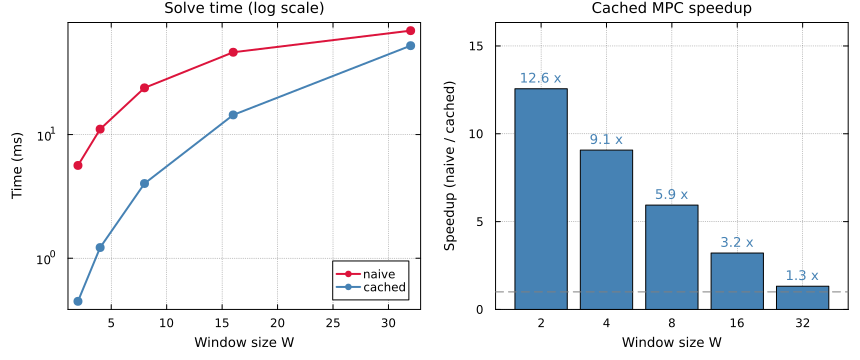

In [9]:
Ws       = [2, 4, 8, 16, 32]
t_naive  = Float64[]
t_cached = Float64[]
for W in Ws
    run_mpc_scenario("", prob2, x0_s2, [traj_s2_1, traj_s2_2], times; window=W, solver=:naive)
    run_mpc_scenario("", prob2, x0_s2, [traj_s2_1, traj_s2_2], times; window=W, solver=:cached)
    tn = minimum(@elapsed(run_mpc_scenario("", prob2, x0_s2, [traj_s2_1, traj_s2_2], times; window=W, solver=:naive))  for _ in 1:7)
    tc = minimum(@elapsed(run_mpc_scenario("", prob2, x0_s2, [traj_s2_1, traj_s2_2], times; window=W, solver=:cached)) for _ in 1:7)
    push!(t_naive, tn); push!(t_cached, tc)
    @printf("W=%-2d  naive %6.2f ms  cached %6.2f ms  speedup %4.1f x\n",
            W, 1e3tn, 1e3tc, tn/tc)
end

speedups = t_naive ./ t_cached

p_speed = plot(layout=(1, 2), size=(860, 360),
               bottom_margin=5Plots.mm, left_margin=5Plots.mm)
plot!(p_speed[1], Ws, 1e3 .* t_naive;
      label="naive",  color=:crimson,   lw=2, marker=:circle, ms=5,
      xlabel="Window size W", ylabel="Time (ms)",
      title="Solve time (log scale)", yaxis=:log,
      legend=:bottomright, grid=true, gridalpha=0.25)
plot!(p_speed[1], Ws, 1e3 .* t_cached;
      label="cached", color=:steelblue, lw=2, marker=:circle, ms=5)
bar!(p_speed[2], string.(Ws), speedups;
     color=:steelblue, legend=false,
     xlabel="Window size W", ylabel="Speedup (naive / cached)",
     title="Cached MPC speedup",
     ylims=(0, maximum(speedups) * 1.3),
     grid=true, gridalpha=0.25)
for (i, s) in enumerate(speedups)
    annotate!(p_speed[2], i - 0.5, s + maximum(speedups) * 0.05,
              text(@sprintf("%.1f x", s), 9, :center, :steelblue))
end
hline!(p_speed[2], [1.0]; color=:gray50, lw=1, ls=:dash, label="")
p_speed